In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/merged_restaurant_data.csv"
)

df.head()

,name,city,province,latitude,longitude,state_name,population
0,Wendy's,Washington Court House,OH,39.53255,-83.44526,Ohio,14439
1,Frisch's Big Boy,Maysville,KY,38.62736,-83.79141,Kentucky,8737
2,OMG! Rotisserie,Athens,OH,39.35155,-82.09728,Ohio,23396
3,Domino's Pizza,Hamilton,OH,39.41760,-84.47641,Ohio,63468
4,Domino's Pizza,Englewood,OH,39.86969,-84.29358,Ohio,13356


In [2]:
df["name"].value_counts().head(20)

name
McDonald's                               1726
Burger King                              1050
Taco Bell                                 802
Wendy's                                   659
Arby's                                    492
KFC                                       390
Domino's Pizza                            313
Subway                                    303
SONIC Drive In                            216
Hardee's                                  186
Jack in the Box                           178
Jimmy John's                              148
Pizza Hut                                 126
Bojangles' Famous Chicken 'n Biscuits     122
Sonic Drive-In                            120
McDonalds                                  99
Chick-fil-A                                92
Five Guys                                  89
Whataburger                                88
Dairy Queen                                86
Name: count, dtype: int64

In [12]:
df["name"] = df["name"].replace(
    {
        "Mcdonald's": "McDonald's"
    }
)

In [13]:
df["name"].value_counts().head(20)

name
McDonald's                               1901
Burger King                              1050
Taco Bell                                 802
Wendy's                                   659
Arby's                                    492
KFC                                       390
Domino's Pizza                            313
Subway                                    303
SONIC Drive In                            216
Hardee's                                  186
Jack in the Box                           178
Jimmy John's                              148
Pizza Hut                                 126
Bojangles' Famous Chicken 'n Biscuits     122
Sonic Drive-In                            120
Chick-fil-A                                92
Five Guys                                  89
Whataburger                                88
Dairy Queen                                86
Taco John's                                74
Name: count, dtype: int64

In [14]:
mcd = df[
    df["name"] == "McDonald's"
].copy()

mcd.shape

(1901, 7)

In [15]:
city_mcd = (
    mcd.groupby(
        ["city", "state_name"]
    )
    .agg(
        mcdonalds_count=("name", "count"),
        population=("population", "first")
    )
    .reset_index()
)

city_mcd.head()

,city,state_name,mcdonalds_count,population
0,Aberdeen,Maryland,1,17298
1,Aberdeen,South Dakota,2,28189
2,Aberdeen,Washington,1,17088
3,Abingdon,Virginia,1,8330
4,Acworth,Georgia,2,22473


In [16]:
city_mcd["mcd_per_100k"] = (
    city_mcd["mcdonalds_count"]
    /
    city_mcd["population"]
) * 100000

In [17]:
city_mcd = city_mcd[
    city_mcd["population"] >= 50000
]

In [18]:
top_10 = (
    city_mcd
    .sort_values(
        "mcd_per_100k",
        ascending=False
    )
    .head(10)
)

top_10

,city,state_name,mcdonalds_count,population,mcd_per_100k
504,Hamilton,Ohio,5,63468,7.877986
1342,Williamsburg,Virginia,5,97985,5.102822
1380,Yakima,Washington,6,136518,4.395025
1008,Pompano Beach,Florida,5,114147,4.380317
1035,Rapid City,South Dakota,4,92897,4.305844
353,Dubuque,Iowa,3,69698,4.304284
794,Michigan City,Indiana,3,72294,4.149722
17,Alexandria,Louisiana,3,76381,3.927678
392,Evansville,Indiana,8,204607,3.909935
1260,Twin Falls,Idaho,2,54164,3.692489


In [19]:
bottom_10 = (
    city_mcd
    .sort_values(
        "mcd_per_100k",
        ascending=True
    )
    .head(10)
)

bottom_10

,city,state_name,mcdonalds_count,population,mcd_per_100k
132,Boston,Massachusetts,1,4453352,0.022455
1109,San Francisco,California,1,3417736,0.029259
882,New York,New York,6,19268388,0.031139
711,Los Angeles,California,5,11984083,0.041722
1061,Riverside,California,1,2333040,0.042863
76,Baltimore,Maryland,1,2201673,0.045420
982,Philadelphia,Pennsylvania,3,5782653,0.051879
1133,Seattle,Washington,2,3642006,0.054915
256,Cleveland,Ohio,1,1695555,0.058978
792,Miami,Florida,4,6391670,0.062581


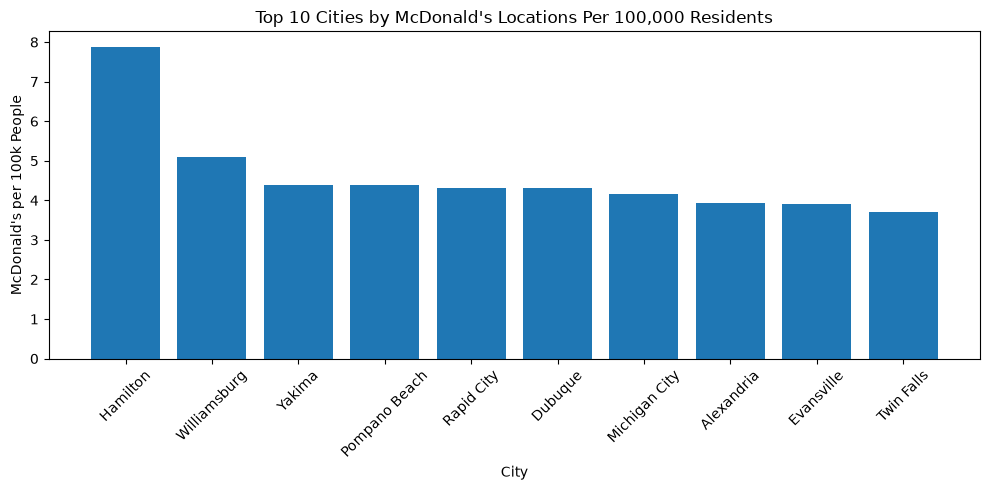

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    top_10["city"],
    top_10["mcd_per_100k"]
)

plt.title(
    "Top 10 Cities by McDonald's Locations Per 100,000 Residents"
)

plt.xlabel("City")
plt.ylabel("McDonald's per 100k People")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/question2_mcdonalds_per_capita.png",
    dpi=300
)

plt.show()